# Client test

In [1]:
from services.simulation_service import simulate_circuit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import time

In [2]:
def dict_builder(nq, clb, initial_state, algorithm, runner_mode, noise_model, shots):
    initial_instructions = []
    for c, i in zip(initial_state, range(nq)):
        if c == '1':
            initial_instructions.append({"name": "X", "qubits": [i]})
    
    if runner_mode == 'shot': algorithm.append({"name": "MEASURE_ALL"})

    instructions = initial_instructions + algorithm
    
    return {
        "name": "Testing",
        "num_qubits": nq,
        "num_clbits": clb,
        "instructions": instructions,
        "runner_mode": runner_mode,
        "noise_model": noise_model,
        "shots": shots
    }

In [19]:
nq = 9
clb = 0
initial_state = '1110'
runner_mode = 'shot'
noise_model = ''
shots = 10000

algorithm_instructions = [
    {"name": "H", "qubits": [0]},
    {"name": "H", "qubits": [1]},
    {"name": "H", "qubits": [2]},
    {"name": "H", "qubits": [3]},
    {"name": "H", "qubits": [4]},
    {"name": "H", "qubits": [5]},
    {"name": "H", "qubits": [6]},
    {"name": "H", "qubits": [7]},
    {"name": "H", "qubits": [8]},
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

In [32]:
result = simulate_circuit(dicccionary, time.time())

counts = result.get('output').get('results')

counts = {k: abs(v) for k, v in counts.items() }

#plot_histogram(counts)
for k, v in counts.items():
    print(f"{k}: {v/shots * 100}")
print(counts)

110011000: 0.22
011100001: 0.1
111111011: 0.11
110101010: 0.13999999999999999
101111010: 0.16999999999999998
110001110: 0.12
110100010: 0.11
010110001: 0.13
101101001: 0.19
101101011: 0.19
101001000: 0.13999999999999999
001111000: 0.2
001101110: 0.2
000010101: 0.21
100111000: 0.21
101100110: 0.2
101111000: 0.22999999999999998
001010111: 0.25
111111101: 0.16999999999999998
001001011: 0.22999999999999998
100101011: 0.18
000010100: 0.18
100101010: 0.18
111100001: 0.2
010101010: 0.25
111101101: 0.21
101010010: 0.21
001010011: 0.2
110001001: 0.15
111110111: 0.16
110101100: 0.13999999999999999
001111100: 0.25
010111010: 0.2
011100010: 0.22
100100001: 0.2
001101000: 0.16
001000101: 0.21
111111100: 0.13
110000010: 0.25
110011011: 0.15
001100001: 0.22
010010101: 0.19
001101101: 0.18
101000111: 0.2
110011111: 0.21
111110010: 0.16999999999999998
111010000: 0.16999999999999998
001011011: 0.16999999999999998
111001111: 0.22
101010000: 0.26
111000001: 0.16
001011110: 0.22
101110010: 0.16
100010101: 

## Circuit Visualization

In [5]:
from services.circuit_service import build_circuit_from_dict

In [6]:
qc = build_circuit_from_dict(dicccionary)

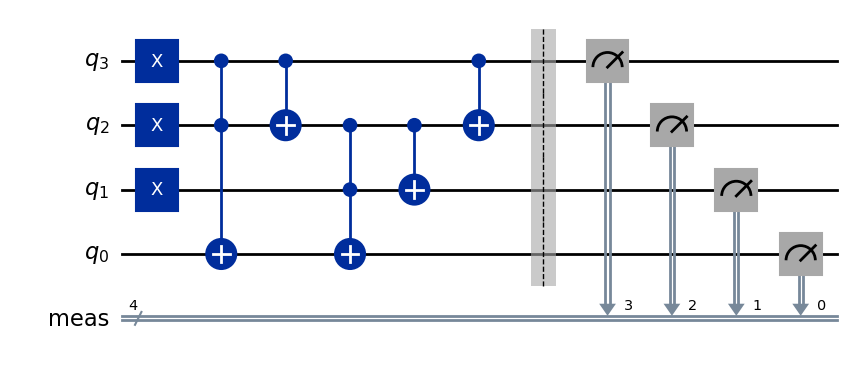

In [7]:
qc.draw('mpl', reverse_bits=True)

# Initialize states

In [8]:

from matplotlib.pylab import sqrt
nq = 2
clb = 0
initial_state = ''
runner_mode = 'statevector'
noise_model = 'depolarizing'
shots = 1024

initial_vector = [sqrt(0.7),sqrt(0.2),sqrt(0.1),0] # 100% state 2 

algorithm_instructions = [
                            {"name": "INITIALIZE", "qubits": [0,1], "params": initial_vector},                              
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

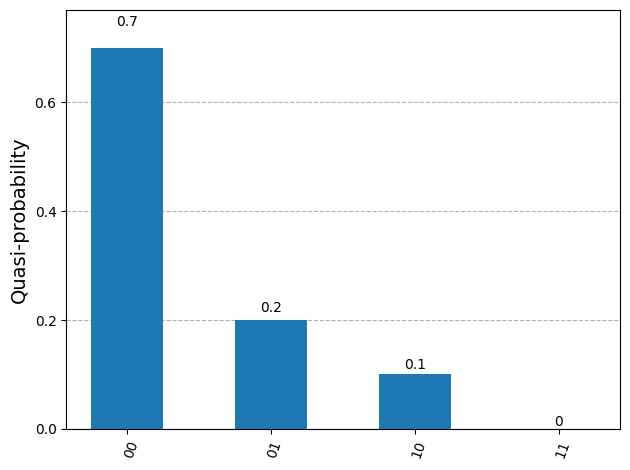

In [10]:
result = simulate_circuit(dicccionary, time.time())

counts = result.get('output').get('results')

counts = {k: abs(v)**2 for k, v in counts.items()}

plot_histogram(counts)

# Quantum furier transform

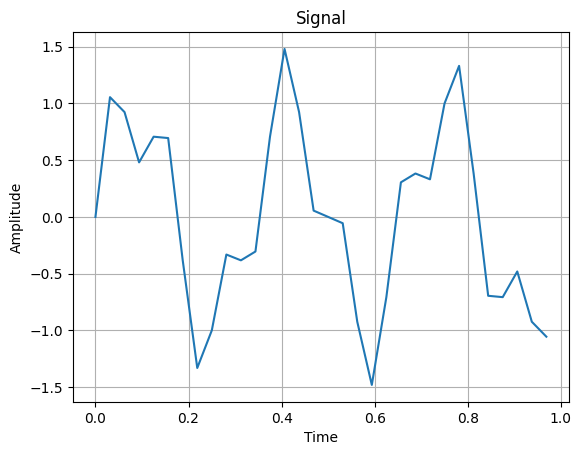

In [11]:
import numpy as np


nq = 5
N = 2**nq

t = np.linspace(0, 1, N, endpoint=False)

frecuencies = [3, 8]

signal = np.sin(2 * np.pi * frecuencies[0] * t) + 0.5 * np.sin(2 * np.pi * frecuencies[1] * t)

n_signal = signal / np.linalg.norm(signal)

plt.plot(t, signal)
plt.title('Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

clb = 0
initial_state = ''
runner_mode = 'shot'
noise_model = ''
shots = 1024

algorithm_instructions = [
                          {"name": "INITIALIZE", "qubits": list(range(nq)), "params": n_signal},
                          {"name": "QFT", "qubits": list(range(nq))}
                        ]
dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

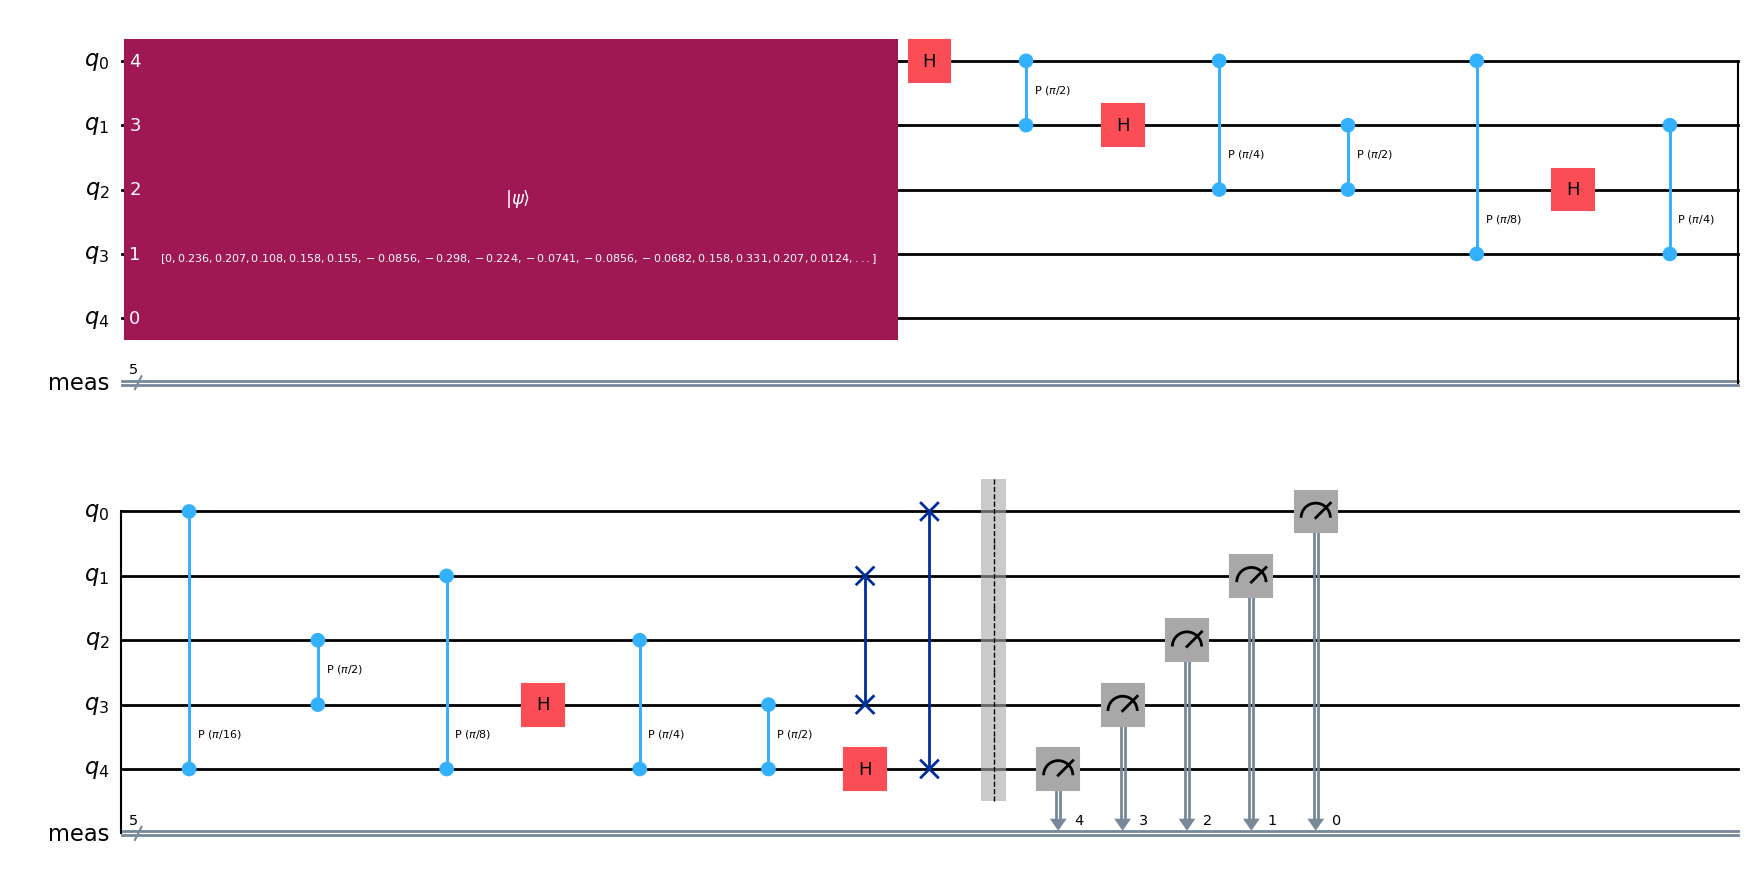

In [12]:
qc = build_circuit_from_dict(dicccionary)

qc.draw('mpl', reverse_bits=False)

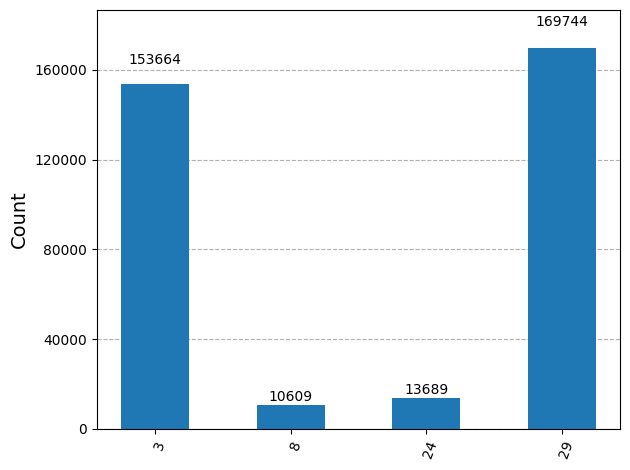

In [13]:
results = simulate_circuit(dicccionary, time.time())

counts = results.get('output').get('results')
counts = {int(k,2): v**2 for k, v in counts.items() if v > 0}

plot_histogram(counts)